# Разработка A/B-тестирования и анализ результатов

## Описание данных

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. 

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. 
- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что сделано 
Задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sessions_history = pd.read_csv('sessions_project_history.csv')

print(sessions_history.head())

            user_id        session_id session_date     session_start_ts  \
0  E302123B7000BFE4  F9AF61A0C2023832   2025-08-15  2025-08-15 17:47:35   
1  2530F72E221829FB  85003A206CBDAC6F   2025-08-15  2025-08-15 16:42:14   
2  876E020A4FC512F5  3677423E49D72DEE   2025-08-15  2025-08-15 12:30:00   
3  2640B349E1D81584  956B45F5915CA225   2025-08-15  2025-08-15 15:31:31   
4  94E1CBFAEF1F5EE9  83BF0DA35F9F1F40   2025-08-15  2025-08-15 21:33:53   

  install_date  session_number  registration_flag  page_counter region  \
0   2025-08-15               1                  0             3    CIS   
1   2025-08-15               1                  0             4   MENA   
2   2025-08-15               1                  0             4     EU   
3   2025-08-15               1                  0             4    CIS   
4   2025-08-15               1                  0             3    CIS   

    device  
0   iPhone  
1  Android  
2       PC  
3  Android  
4  Android  


#### 1.2. Знакомство с данными

In [3]:
user_sessions_count = sessions_history.groupby('user_id')['session_id'].nunique()

max_sessions_user = user_sessions_count.idxmax()

user_data = sessions_history[sessions_history['user_id'] == max_sessions_user]

display(user_data)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций

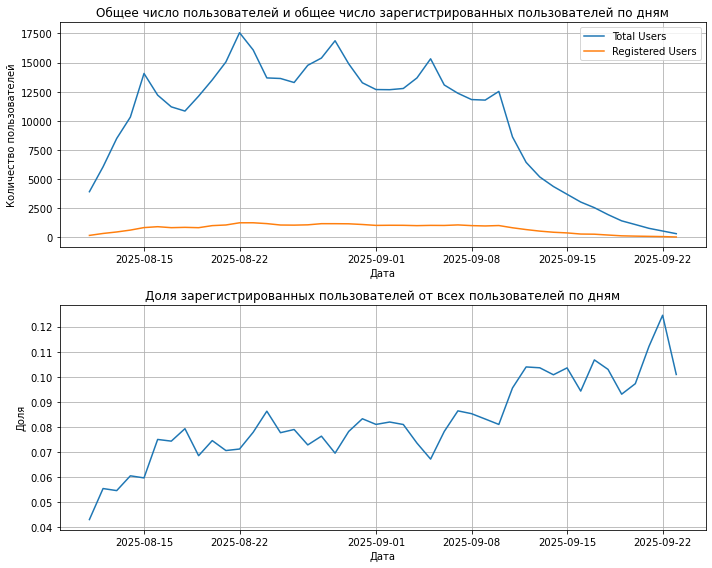

In [4]:
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

daily_data = sessions_history.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),
    registered_users=('registration_flag', lambda x: x.sum() if x.name == 'registration_flag' else None)
)

daily_data['registration_rate'] = daily_data['registered_users'] / daily_data['total_users']

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(daily_data.index, daily_data['total_users'], label='Total Users')
ax[0].plot(daily_data.index, daily_data['registered_users'], label='Registered Users')
ax[0].set_title('Общее число пользователей и общее число зарегистрированных пользователей по дням')
ax[0].set_xlabel('Дата')
ax[0].set_ylabel('Количество пользователей')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(daily_data.index, daily_data['registration_rate'])
ax[1].set_title('Доля зарегистрированных пользователей от всех пользователей по дням')
ax[1].set_xlabel('Дата')
ax[1].set_ylabel('Доля')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Мы можем наблюдать сокращение общего числа пользователей и общего числа зарегистрированных пользователей по дням.
Но при этом доля зарегистрированных пользовователей от всех пользователей по дням имеет тенденцию к увеличению. 

#### 1.4. Анализ числа просмотренных страниц

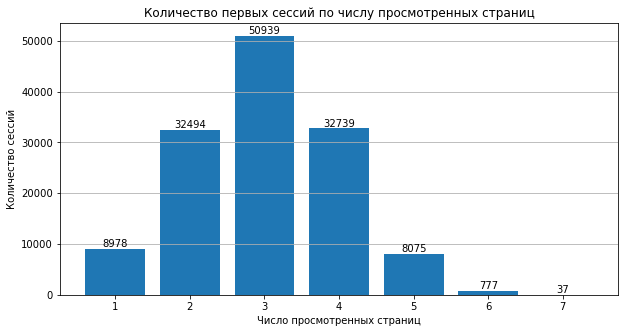

In [5]:
first_sessions = sessions_history[sessions_history['session_number'] == 1]

page_views_count = first_sessions.groupby('page_counter').size().reset_index(name='session_count')

plt.figure(figsize=(10, 5))
bars = plt.bar(page_views_count['page_counter'], page_views_count['session_count'])  

for bar in bars:
    height = bar.get_height()  
    plt.text(bar.get_x() + bar.get_width() / 2., height + 0.1, 
             f'{int(height)}',  
             ha='center', va='bottom')  

plt.title('Количество первых сессий по числу просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid(axis='y')
plt.show()

Одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях, три страницы - в 50 939 первых сессиях, четыре страницы - в 32 739 первых сессиях, пять страниц - в 8 075 первых сессиях, шесть страниц - в 777 первых сессиях, семь страниц - в 37 первых сессиях. 
Из предоставленных данных видно, что большинство пользователей просматривают более одной страницы в своих первых сессиях, при этом пик приходится на три страницы — их просмотрели в 50 939 сессиях. С увеличением количества страниц число сессий уменьшается, что может свидетельствовать о снижении интереса или сложности удержания внимания пользователя. Тем не менее, тот факт, что значительное количество пользователей просматривают более двух-трёх страниц, говорит о том, что контент или функционал приложения способны удерживать внимание на начальном этапе взаимодействия.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

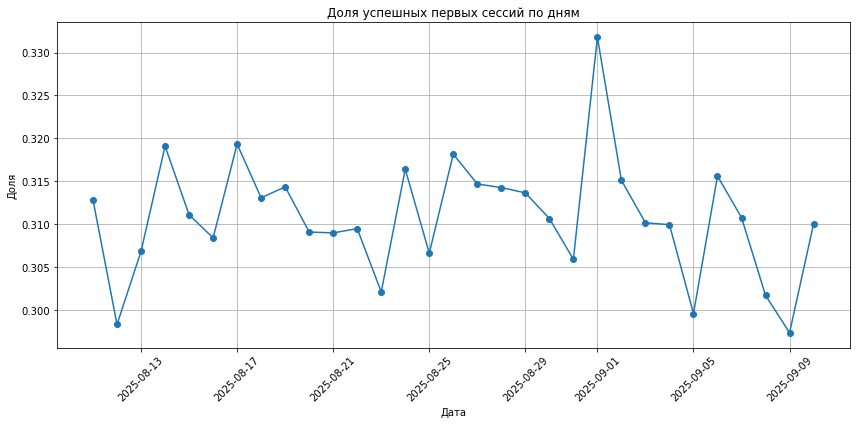

In [6]:
sessions_history['good_session'] = sessions_history['page_counter'].apply(
    lambda x: 1 if x >= 4 else 0
)

first_sessions = sessions_history[sessions_history['session_number'] == 1]

daily_first_sessions = first_sessions.groupby('session_date').agg(
    total_first_sessions=('session_id', 'count'),
    good_first_sessions=('good_session', 'sum')
).reset_index()

daily_first_sessions['good_session_rate'] = (
    daily_first_sessions['good_first_sessions'] /
    daily_first_sessions['total_first_sessions']
)

plt.figure(figsize=(12, 6))
plt.plot(daily_first_sessions['session_date'], daily_first_sessions['good_session_rate'], marker='o')
plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid(True)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

Среднее значение доли успешных первых сессий варьируется в диапазоне примерно от 29 % до 33,2 %.
Это значит, что в среднем чуть более трети первых сессий можно считать «успешными».

### 2. Подготовка к тесту

#### 2.1. Расчёт размера выборки

In [7]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

alpha = 0.05  
beta = 0.2    
power = 1 - beta
p = 0.3       
relative_mde = 0.03  

mde = p * relative_mde

effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

In [8]:
from math import ceil

daily_users = sessions_history.groupby('session_date')['user_id'].nunique()
avg_daily_users = daily_users.mean()

total_sample_size = 2 * sample_size
test_duration = ceil(total_sample_size / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

Количество уникальных пользователей в группе A: 1477
Количество уникальных пользователей в группе B: 1466
Процентная разница в количестве пользователей: 0.74%


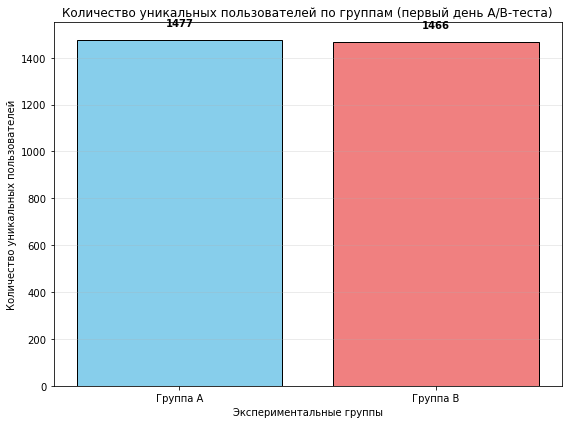

In [9]:
sessions_test_part = pd.read_csv('sessions_project_test_part.csv')

users_by_group = sessions_test_part.groupby('test_group')['user_id'].nunique()

group_A_users = users_by_group.loc['A']
group_B_users = users_by_group.loc['B']

print(f"Количество уникальных пользователей в группе A: {group_A_users}")
print(f"Количество уникальных пользователей в группе B: {group_B_users}")

if group_A_users > 0:  
    percentage_difference = 100 * abs(group_A_users - group_B_users) / group_A_users
else:
    percentage_difference = float('nan')  
print(f"Процентная разница в количестве пользователей: {percentage_difference:.2f}%")

plt.figure(figsize=(8, 6))
bars = plt.bar(['Группа A', 'Группа B'], [group_A_users, group_B_users], 
               color=['skyblue', 'lightcoral'], edgecolor='black')

plt.title('Количество уникальных пользователей по группам (первый день A/B‑теста)')
plt.xlabel('Экспериментальные группы')
plt.ylabel('Количество уникальных пользователей')

for bar, count in zip(bars, [group_A_users, group_B_users]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Таким образом, распределение пользователей между группами A и B практически одинаково: разница составляет всего 0,74%. Это говорит о том, что группы хорошо сбалансированы по количеству участников, что важно для проведения корректного A/B-теста.

#### 3.2. Проверка пересечений пользователей

In [10]:
users_in_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].unique()
users_in_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].unique()

common_users = set(users_in_A).intersection(set(users_in_B))

num_common_users = len(common_users)

if num_common_users == 0:
    print("Группы независимы")
else:
    print(f"{num_common_users} пользователей попали в обе группы")

Группы независимы


#### 3.3. Равномерность разделения пользователей по устройствам

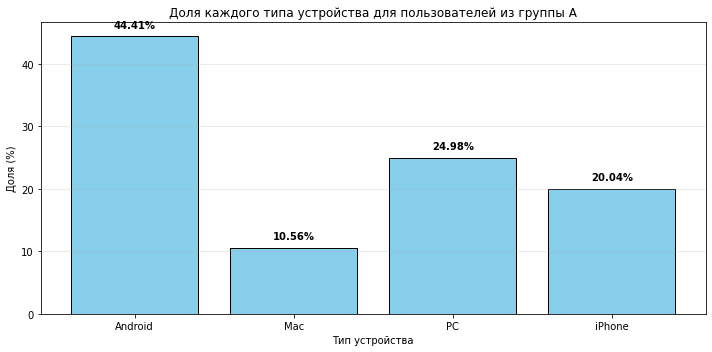

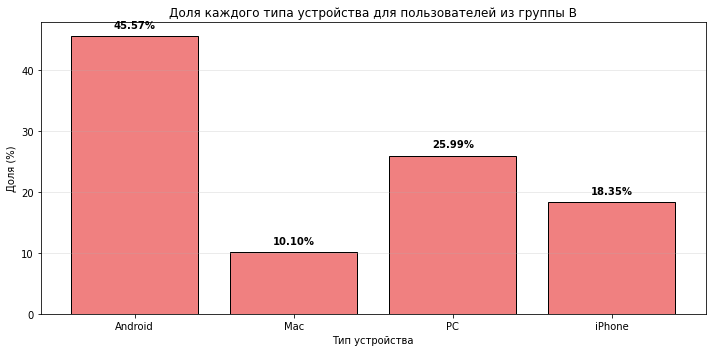

In [11]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']

unique_devices_A = group_A.groupby('device')['user_id'].nunique()
unique_devices_B = group_B.groupby('device')['user_id'].nunique()

device_shares_A = unique_devices_A / unique_devices_A.sum() * 100
device_shares_B = unique_devices_B / unique_devices_B.sum() * 100

plt.figure(figsize=(10, 5))
bars_A = plt.bar(device_shares_A.index, device_shares_A, color='skyblue', edgecolor='black')
plt.title('Доля каждого типа устройства для пользователей из группы A')
plt.xlabel('Тип устройства')
plt.ylabel('Доля (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for bar, count in zip(bars_A, device_shares_A):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{count:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.show()

plt.figure(figsize=(10, 5))
bars_B = plt.bar(device_shares_B.index, device_shares_B, color='lightcoral', edgecolor='black')
plt.title('Доля каждого типа устройства для пользователей из группы B')
plt.xlabel('Тип устройства')
plt.ylabel('Доля (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for bar, count in zip(bars_B, device_shares_B):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{count:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.show()

Из представленных данных можно сделать вывод о том, что распределение устройств в группах A и В совпадает.

#### 3.4. Равномерность распределения пользователей по регионам

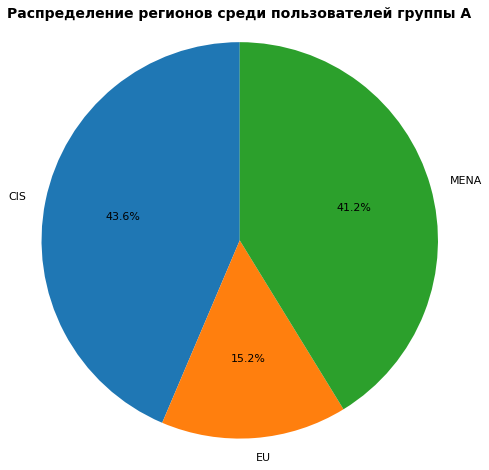

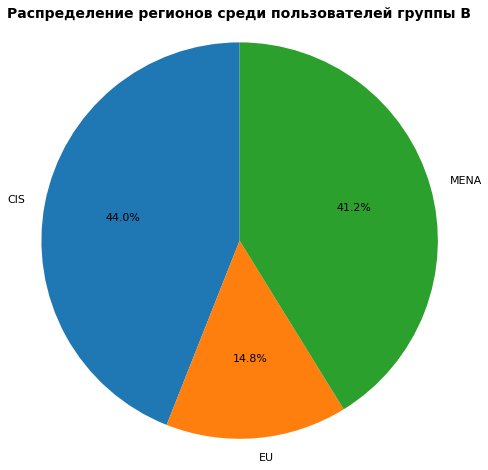

In [12]:
unique_regions_A = group_A.groupby('region')['user_id'].nunique()
unique_regions_B = group_B.groupby('region')['user_id'].nunique()

region_shares_A = unique_regions_A / unique_regions_A.sum() * 100
region_shares_B = unique_regions_B / unique_regions_B.sum() * 100

plt.figure(figsize=(8, 8))
plt.pie(
    region_shares_A,
    labels=region_shares_A.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
plt.title('Распределение регионов среди пользователей группы A', fontsize=14, fontweight='bold')
plt.axis('equal') 
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(
    region_shares_B,
    labels=region_shares_B.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
plt.title('Распределение регионов среди пользователей группы B', fontsize=14, fontweight='bold')
plt.axis('equal') 
plt.show()

Можно сделать вывод о том, что распределение регионов в группах A и B совпадает.

#### 3.5. Вывод после проверки A/B-теста

1. Различие в количестве пользователей в двух группах не обнаружено. 
2. Выборки независимыми. Пересечение пользователей из тестовой и контрольной групп не обнаружено.
3. Сохраняется равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Таким образом, A/B-тест проходит корректно.

### 4. Проверка результатов A/B-теста

#### 4.1. Получение результатов теста и подсчёт основной метрики

In [13]:
sessions_test = pd.read_csv('sessions_project_test.csv')

sessions_test['good_session'] = sessions_test['page_counter'].apply(lambda x: 1 if x >= 4 else 0)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

Нулевая гипотеза: новый алгоритм рекомендательной системы не приведёт к значимому изменению интереса пользователей.
Альтернативная гипотеза: новый алгоритм повысит интерес пользователей, что отразится в увеличении выбранной метрики (например, среднего количества просмотренных страниц на пользователя).

Прокси-метрики: 
- Среднее количество просмотров на пользователя. 
- Время, проведённое пользователем в приложении.

Барьерная метрика: 
- Уровень отказов.

#### 4.3. Сравнение доли успешных первых сессий

In [14]:
group_A = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]
group_B = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]

success_rate_A = group_A['good_session'].mean()
success_rate_B = group_B['good_session'].mean()

difference = success_rate_B - success_rate_A

print(f"Доля успешных первых сессий в группе A: {success_rate_A:.2%}")
print(f"Доля успешных первых сессий в группе B: {success_rate_B:.2%}")
print(f"Разница в доле успешных первых сессий: {difference:.2%}")

Доля успешных первых сессий в группе A: 31.57%
Доля успешных первых сессий в группе B: 31.47%
Разница в доле успешных первых сессий: -0.11%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

In [15]:
from statsmodels.stats.proportion import proportions_ztest

sessions_test = pd.read_csv('sessions_project_test.csv')

if 'good_session' not in sessions_test.columns:
    sessions_test['good_session'] = sessions_test['page_counter'].apply(lambda x: 1 if x >= 4 else 0)

group_A = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]
group_B = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]

counts = [group_A['good_session'].sum(), group_B['good_session'].sum()] 
nobs = [len(group_A), len(group_B)] 

z_stat, p_value = proportions_ztest(counts, nobs, alternative='smaller')

print(f"z-статистика: {z_stat}")
print(f"p-value: {p_value}")

alpha = 0.05  
if p_value < alpha:
    print("Доля успешных первых сессий в группе B статистически значимо выше, чем в группе A — гипотеза об улучшении подтверждается.")
else:
    print("Не удалось обнаружить статистически значимого улучшения доли успешных первых сессий в группе B по сравнению с группой A.")


z-статистика: 0.19768021528115556
p-value: 0.5783523649187868
Не удалось обнаружить статистически значимого улучшения доли успешных первых сессий в группе B по сравнению с группой A.


#### 4.5. Вывод по результатам A/B-эксперимента

Характеристики проведённого эксперимента: количество уникальных пользователей в группе A - 1477, в группе B - 1466. Длительность эксперимента: 9 дней. 

Внедрение нового алгоритма рекомендаций не привело к увеличению доли успешных первых сессий в группе B по сравнению с группой A (разница в доле успешных первых сессий: -0,11 %)

Значение p-value для оценки статистической значимости выявленного эффекта: 0.578. 

На основании результатов эксперимента не выявлено статистически значимого влияния нового алгоритма рекомендаций на долю успешных первых сессий. Наблюдаемая разница (−0,11 %) незначительна и может быть объяснена случайными колебаниями — об этом свидетельствует высокое значение p‑value (0,578), которое существенно превышает порог значимости 0,05.

Таким образом, нет достаточных оснований для рекомендации внедрения нового алгоритма в приложение.